# BITCOIN PRICE PREDICTOR

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error as rmse


In [2]:
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0 -> 25.3
[notice] To update, run: C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [2]:
import yfinance as yf

In [8]:
data = yf.download("BTC-USD", "2024-01-01", "2026-06-25", auto_adjust=True)
data.tail()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2026-06-20,64239.675781,64307.136719,63149.660156,63535.808594,17486384117
2026-06-21,63237.539062,64506.578125,63221.000000,64242.324219,15739619591
2026-06-22,63952.105469,65544.000000,63233.531250,63240.789062,26561496819
2026-06-23,62668.019531,64196.562500,61893.207031,63952.792969,29608942370
2026-06-24,60995.132812,63097.757812,59029.855469,62663.031250,42644106535


In [5]:
data.shape

(906, 5)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 906 entries, 2024-01-01 to 2026-06-24
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, BTC-USD)   906 non-null    float64
 1   (High, BTC-USD)    906 non-null    float64
 2   (Low, BTC-USD)     906 non-null    float64
 3   (Open, BTC-USD)    906 non-null    float64
 4   (Volume, BTC-USD)  906 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 42.5 KB


In [7]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
count,906.000000,906.000000,906.000000,906.000000,9.060000e+02
mean,81996.692277,83390.996400,80475.440152,81975.808594,4.397978e+10
std,20705.310147,20876.974744,20541.274132,20735.635736,2.304622e+10
min,39507.367188,40127.351562,38521.894531,39518.714844,9.344044e+09
25%,65609.306641,66943.375000,63932.939453,65608.986328,2.763705e+10
50%,79451.628906,81554.632812,78052.519531,79450.996094,3.968728e+10
75%,98329.193359,100461.072266,96413.878906,98334.242188,5.482933e+10
max,124752.531250,126198.070312,123196.046875,124752.140625,1.817464e+11


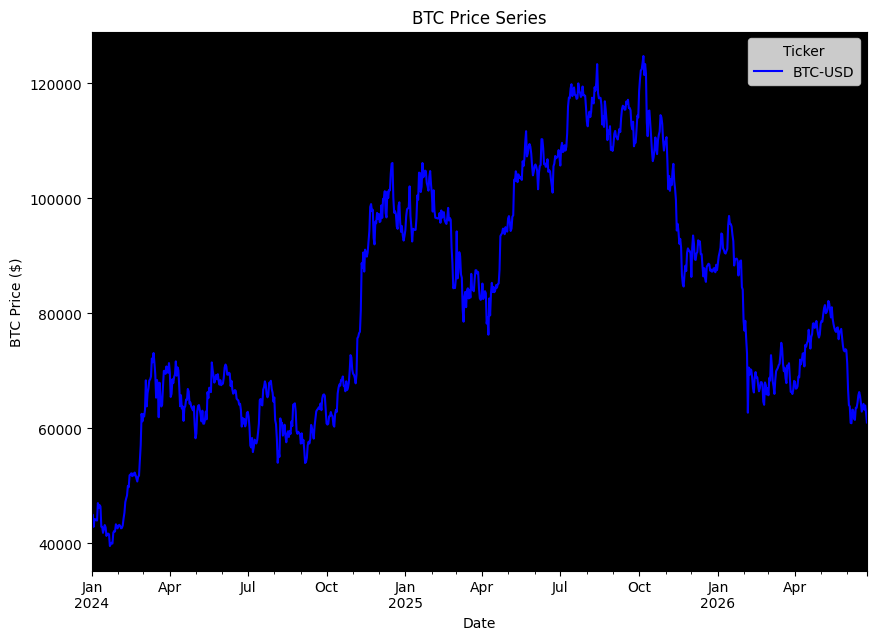

In [10]:
data.Close.plot(figsize=(10,7), color='b').set_facecolor('black')
plt.ylabel('BTC Price ($)')
plt.title('BTC Price Series')
plt.show()

<Axes: ylabel='Count'>

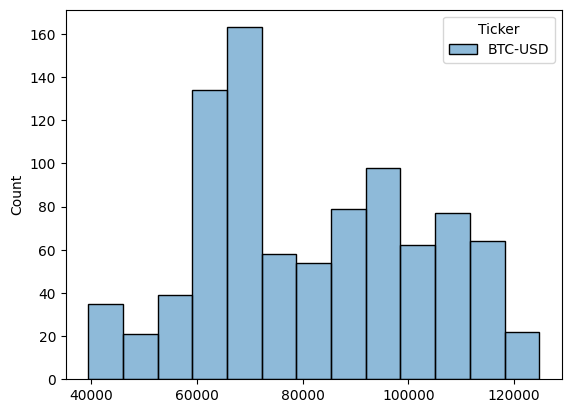

In [11]:
sns.histplot(data["Close"])

<Axes: ylabel='Count'>

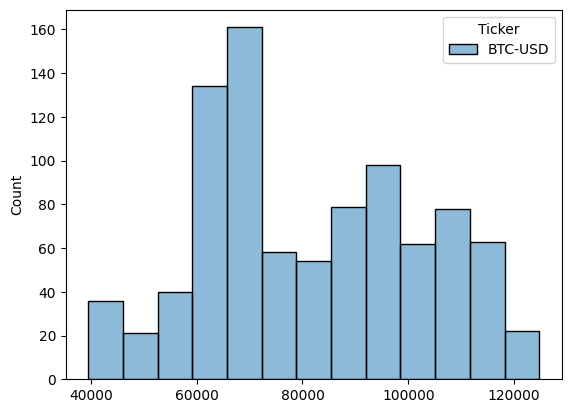

In [12]:
sns.histplot(data["Open"])

<Axes: ylabel='Count'>

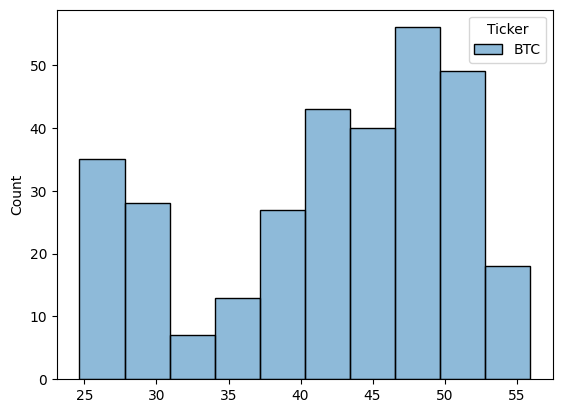

In [11]:
sns.histplot(data["High"])

In [17]:
X = data.drop('Close', axis=1)
y = data['Close']

In [32]:
X_train, y_train = X.iloc[0:int(0.8*960)], y.iloc[0:int(0.8*960)]
X_test, y_test = X.iloc[int(0.8*960):], y.iloc[int(0.8*960):]

In [33]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((768, 4), (138, 4), (768, 1), (138, 1))

# UTILS

In [48]:
model_names = []
model_rmse = []
model_r2_score = []

In [51]:
from datetime import datetime
from sklearn.metrics import root_mean_squared as rmse
from sklearn.metrics import r2_score
import joblib

def eval_save_model(model):
    name = model.__class__.__name__
    rmse_model = rmse(model.predict(X_test), y_test)
    r2_score_model = r2_score(model.predict(X_test), y_test)
    
    model_names.append(name)
    model_rmse.append(rmse_model)
    model_r2_score.append(r2_score_model)
    return f'{name}:\n\tRMSE:{rmse_model}\n\tR2-score:{r2_score_model}'

def save_perfs(perfs, fname=None):
    if fname is None:
        fname = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    perfs.to_csv(f'models/perfs/{fname}.csv')

def save_model(model, fname):
    joblib.dump(model, f'models/saved{fname}.pkl',compress=3)

ImportError: cannot import name 'root_mean_squared' from 'sklearn.metrics' (C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\__init__.py)

### LINEAR REGRESSION 

In [34]:
y_train

Ticker,BTC-USD
Date,
2024-01-01,44167.332031
2024-01-02,44957.968750
2024-01-03,42848.175781
2024-01-04,44179.921875
2024-01-05,44162.691406
...,...
2026-02-02,78688.765625
2026-02-03,75633.546875
2026-02-04,73019.703125


In [35]:
from sklearn.linear_model import LinearRegression

lr  = LinearRegression().fit(X_train, y_train)

predict = lr.predict(X_test)
print(predict)

[[69192.02100764]
 [71366.94412272]
 [69773.32161524]
 [68780.45854537]
 [67003.42012411]
 [66741.6550878 ]
 [68553.31511511]
 [70023.69032041]
 [69480.4437019 ]
 [68742.04710838]
 [67504.31919713]
 [67051.97927993]
 [66496.15197774]
 [67640.2375207 ]
 [68098.44909284]
 [67500.49917375]
 [65014.72838068]
 [63428.35266569]
 [68913.23936907]
 [67631.0441069 ]
 [66281.41142658]
 [65411.75235223]
 [66566.52686687]
 [69036.37098713]
 [67325.85895511]
 [72561.51590311]
 [71920.45534267]
 [69075.73945176]
 [67524.8274805 ]
 [66808.38095575]
 [68794.1138147 ]
 [71188.42747137]
 [70388.75123451]
 [69912.03654357]
 [73282.98983993]
 [70671.19951733]
 [72519.6516562 ]
 [74157.40596082]
 [74744.89639083]
 [72084.03315896]
 [69764.21686781]
 [70669.70691397]
 [69510.57149153]
 [68379.497886  ]
 [70847.06699161]
 [69824.43761275]
 [71555.75478706]
 [69089.22882675]
 [66737.41100437]
 [66671.77566719]
 [65887.55910247]
 [67532.26821529]
 [67621.87109404]
 [68507.23701052]
 [66830.48035079]
 [66689.32

In [37]:
from sklearn.metrics import r2_score

print("Root Mean Square Error: {}".format(rmse(predict, y_test)))
print("R2 score: {}".format(r2_score(y_test, predict)))

Root Mean Square Error: 575.8762008906998
R2 score: 0.9891333653077922


In [38]:
from sklearn.linear_model import Lasso, Ridge

la = Lasso().fit(X_train, y_train)
ri = Ridge().fit(X_train, y_train)

la_pred = la.predict(X_test)
ri_pred = ri.predict(X_test)

C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.615e+08, tolerance: 3.643e+07
  model = cd_fast.enet_coordinate_descent(


In [40]:
#Lasso regularization

print("Using Lasso Regularization")
print("\t-Root Mean Square Error: {}".format(rmse(y_test, la_pred)))
print("\t-R2 score: {}".format(r2_score(y_test, predict)))

Using Lasso Regularization
	-Root Mean Square Error: 582.3962390276511
	-R2 score: 0.9891333653077922


In [41]:
#Ridge regularization

print("Using Ridge Regularization")
print("\t-Root Mean Square Error: {}".format(rmse(y_test, ri_pred)))
print("\t-R2 score: {}".format(r2_score(y_test, ri_pred)))

Using Ridge Regularization
	-Root Mean Square Error: 575.8762009346067
	-R2 score: 0.9891333653061352


### SUPPORT VECTOR MACHINE

In [42]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

svm = SVR()

param_grid = {'C':[0.1,1,10,100,1000], 'gamma': [1,0.1,0.01,0.001,0.0001], 'kernel':['rbf']}

grid = GridSearchCV(SVR(), param_grid, refit=True, verbose=3)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ......C=0.1, gamma=1, kernel=rbf;, score=-10.935 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=1, kernel=rbf;, score=-50.294 total time=   0.0s


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV 3/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-7.017 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=1, kernel=rbf;, score=-11.357 total time=   0.0s
[CV 5/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-4.260 total time=   0.0s
[CV 1/5] END ....C=0.1, gamma=0.1, kernel=rbf;, score=-10.935 total time=   0.0s


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\valid

[CV 2/5] END ....C=0.1, gamma=0.1, kernel=rbf;, score=-50.294 total time=   0.0s
[CV 3/5] END .....C=0.1, gamma=0.1, kernel=rbf;, score=-7.017 total time=   0.0s
[CV 4/5] END ....C=0.1, gamma=0.1, kernel=rbf;, score=-11.357 total time=   0.0s


...

[CV 2/5] END .C=1000, gamma=0.001, kernel=rbf;, score=-49.906 total time=   0.0s
[CV 3/5] END ..C=1000, gamma=0.001, kernel=rbf;, score=-7.000 total time=   0.0s
[CV 4/5] END .C=1000, gamma=0.001, kernel=rbf;, score=-11.149 total time=   0.0s
[CV 5/5] END ..C=1000, gamma=0.001, kernel=rbf;, score=-4.240 total time=   0.0s


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\valid

[CV 1/5] END C=1000, gamma=0.0001, kernel=rbf;, score=-10.862 total time=   0.0s
[CV 2/5] END C=1000, gamma=0.0001, kernel=rbf;, score=-49.906 total time=   0.0s
[CV 3/5] END .C=1000, gamma=0.0001, kernel=rbf;, score=-7.000 total time=   0.0s
[CV 4/5] END C=1000, gamma=0.0001, kernel=rbf;, score=-11.149 total time=   0.0s
[CV 5/5] END .C=1000, gamma=0.0001, kernel=rbf;, score=-4.240 total time=   0.0s


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GridSearchCV(estimator=SVR(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [43]:
best_params = grid.best_params_

print("Best obtained score:{}, for parameters: {}".format(grid.best_score_, best_params))

Best obtained score:-16.63122147584623, for parameters: {'C': 1000, 'gamma': 1, 'kernel': 'rbf'}


In [44]:
svr = SVR(C=10, gamma=0.0001, kernel='rbf')
svr.fit(X_train, y_train)
svr_predict = svr.predict(X_test)


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [46]:
#SVM 
print("Using SVM")
print("\t-SVM Mean Square Error: {}".format(rmse(y_test, svr_predict)))
print("\t-R2 score: {}".format(r2_score(y_test, ri_pred)))

Using SVM
	-SVM Mean Square Error: 17109.128666524226
	-R2 score: 0.9891333653061352


In [49]:
import joblib

best_model = joblib.dump(ri, 'model.pkl') #Because ridge has the best performances